# Image Reconstruction Using an Autoencoder

This project explores how an autoencoder can learn to reconstruct handwritten images.

In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("PyTorch is working!")

PyTorch version: 2.14.0+cpu
PyTorch is working!


In [2]:
from torchvision import datasets

train_data = datasets.MNIST(
    root="../data",
    train=True,
    download=True
)

print("Number of training images:", len(train_data))

100.0%
100.0%
100.0%
100.0%

Number of training images: 60000


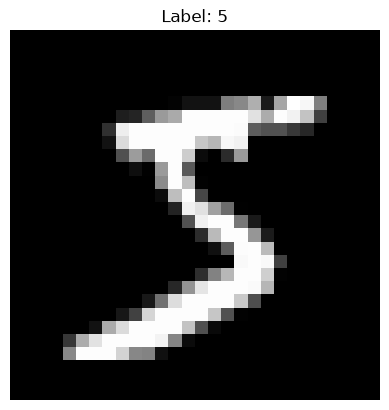

In [4]:
import matplotlib.pyplot as plt

image, label = train_data[0]

plt.imshow(image, cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

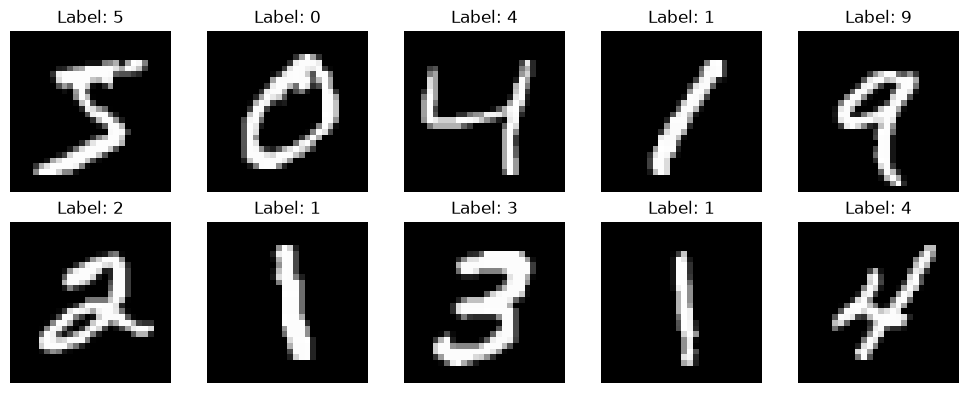

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    image, label = train_data[i]
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
from torchvision import transforms

transform = transforms.ToTensor()

train_data = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=transform
)

image, label = train_data[0]

print("Image shape:", image.shape)
print("Label:", label)

Image shape: torch.Size([1, 28, 28])
Label: 5


In [7]:
print(image)

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [8]:
flat_image = image.view(-1)

print("Original shape:", image.shape)
print("Flattened shape:", flat_image.shape)

Original shape: torch.Size([1, 28, 28])
Flattened shape: torch.Size([784])


In [9]:
import torch.nn as nn

encoder = nn.Sequential(
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 32)
)

print(encoder)

Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=32, bias=True)
)


In [10]:
latent = encoder(flat_image)

print("Latent shape:", latent.shape)

Latent shape: torch.Size([32])


In [11]:
decoder = nn.Sequential(
    nn.Linear(32, 128),
    nn.ReLU(),
    nn.Linear(128, 784),
    nn.Sigmoid()
)

print(decoder)

Sequential(
  (0): Linear(in_features=32, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=784, bias=True)
  (3): Sigmoid()
)


In [12]:
autoencoder = nn.Sequential(
    encoder,
    decoder
)

print(autoencoder)

Sequential(
  (0): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=32, bias=True)
  )
  (1): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=784, bias=True)
    (3): Sigmoid()
  )
)


In [13]:
loss_function = nn.MSELoss()

print(loss_function)

MSELoss()


In [14]:
optimizer = torch.optim.Adam(
    autoencoder.parameters(),
    lr=0.001
)

print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [15]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

print("Number of batches:", len(train_loader))

Number of batches: 938


In [16]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])


In [17]:
images = images.view(images.size(0), -1)

print("Flattened images shape:", images.shape)

Flattened images shape: torch.Size([64, 784])


In [18]:
reconstructed = autoencoder(images)

print("Reconstructed shape:", reconstructed.shape)

Reconstructed shape: torch.Size([64, 784])


In [19]:
loss = loss_function(reconstructed, images)

print("Loss:", loss.item())

Loss: 0.23177611827850342


In [20]:
optimizer.zero_grad()
loss.backward()
optimizer.step()

print("Weights updated successfully!")

Weights updated successfully!


In [21]:
reconstructed = autoencoder(images)

In [22]:
print("New reconstructed shape:", reconstructed.shape)

New reconstructed shape: torch.Size([64, 784])


In [23]:
new_loss = loss_function(reconstructed, images)

print("New loss:", new_loss.item())

New loss: 0.23005403578281403


In [24]:
for images, labels in train_loader:
    print(images.shape)
    break

torch.Size([64, 1, 28, 28])


In [25]:
for images, labels in train_loader:
    images = images.view(images.size(0), -1)

In [26]:
for images, labels in train_loader:
    images = images.view(images.size(0), -1)

    reconstructed = autoencoder(images)

In [27]:
for images, labels in train_loader:
    images = images.view(images.size(0), -1)

    reconstructed = autoencoder(images)

    loss = loss_function(reconstructed, images)

In [28]:
optimizer.zero_grad()
loss.backward()

In [29]:
optimizer.step()

In [30]:
num_epochs = 10

for epoch in range(num_epochs):

    total_loss = 0

    for images, labels in train_loader:

        # Flatten the images
        images = images.view(images.size(0), -1)

        # Reconstruct the images
        reconstructed = autoencoder(images)

        # Calculate the loss
        loss = loss_function(reconstructed, images)

        # Clear old gradients
        optimizer.zero_grad()

        # Calculate new gradients
        loss.backward()

        # Update the model's weights
        optimizer.step()

        # Add this batch's loss
        total_loss += loss.item()

    # Calculate the average loss for this epoch
    average_loss = total_loss / len(train_loader)

    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {average_loss:.4f}")

Epoch [1/10], Loss: 0.0363
Epoch [2/10], Loss: 0.0151
Epoch [3/10], Loss: 0.0118
Epoch [4/10], Loss: 0.0103
Epoch [5/10], Loss: 0.0093
Epoch [6/10], Loss: 0.0085
Epoch [7/10], Loss: 0.0080
Epoch [8/10], Loss: 0.0076
Epoch [9/10], Loss: 0.0073
Epoch [10/10], Loss: 0.0071


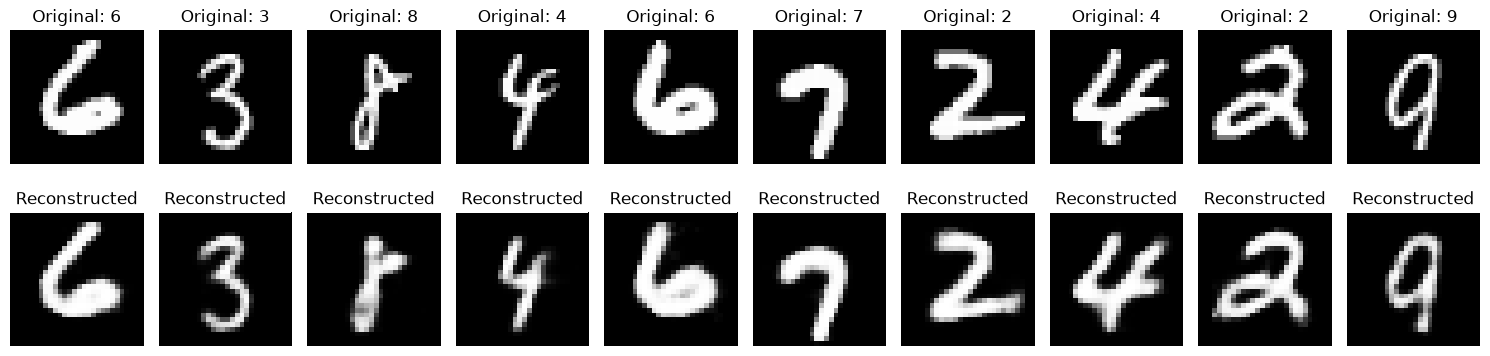

In [31]:
import matplotlib.pyplot as plt

# Get one batch of images
images, labels = next(iter(train_loader))

# Flatten the images so they can go through the autoencoder
images_flat = images.view(images.size(0), -1)

# Reconstruct the images
with torch.no_grad():
    reconstructed = autoencoder(images_flat)

# Create a figure
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

# Show original images
for i in range(10):
    original = images[i].squeeze()
    
    axes[0, i].imshow(original, cmap="gray")
    axes[0, i].set_title(f"Original: {labels[i].item()}")
    axes[0, i].axis("off")

# Show reconstructed images
for i in range(10):
    reconstruction = reconstructed[i].view(28, 28)
    
    axes[1, i].imshow(reconstruction, cmap="gray")
    axes[1, i].set_title("Reconstructed")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

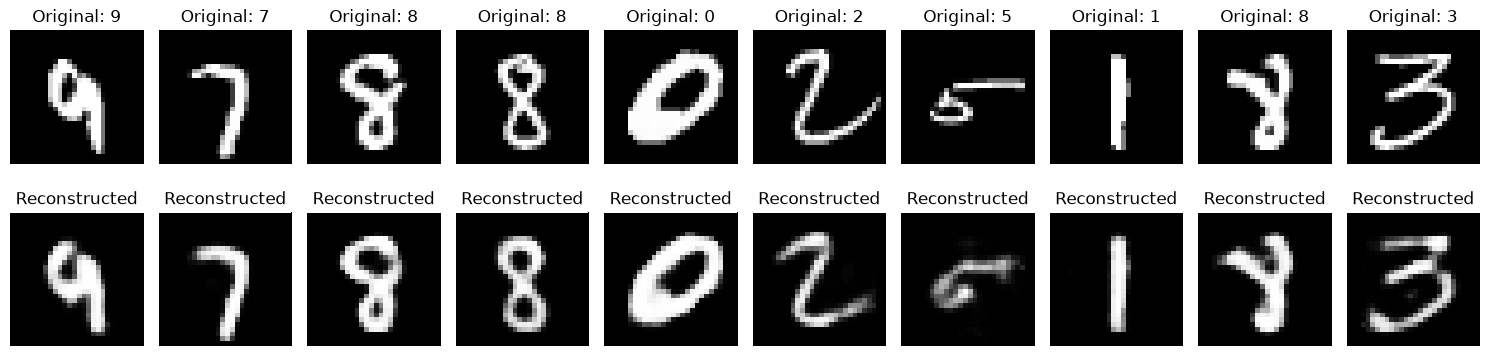

Saved to: c:\Users\safur\Desktop\image-autoencoder\images\reconstruction_results.png


In [32]:
import matplotlib.pyplot as plt
import torch
from pathlib import Path

# -----------------------------------
# 1. Get one batch of images
# -----------------------------------
images, labels = next(iter(train_loader))

# -----------------------------------
# 2. Flatten the images
# -----------------------------------
images_flat = images.view(images.size(0), -1)

# -----------------------------------
# 3. Reconstruct the images
# -----------------------------------
with torch.no_grad():
    reconstructed = autoencoder(images_flat)

# -----------------------------------
# 4. Create the comparison figure
# -----------------------------------
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

# Original images
for i in range(10):
    axes[0, i].imshow(
        images[i].squeeze(),
        cmap="gray"
    )
    axes[0, i].set_title(
        f"Original: {labels[i].item()}"
    )
    axes[0, i].axis("off")

# Reconstructed images
for i in range(10):
    axes[1, i].imshow(
        reconstructed[i].view(28, 28),
        cmap="gray"
    )
    axes[1, i].set_title("Reconstructed")
    axes[1, i].axis("off")

plt.tight_layout()

# -----------------------------------
# 5. Create the images folder
# -----------------------------------
project_dir = Path.cwd()

# If VS Code is running from the notebook folder,
# move one level up to the project folder.
if project_dir.name == "notebook":
    project_dir = project_dir.parent

output_dir = project_dir / "images"
output_dir.mkdir(exist_ok=True)

# -----------------------------------
# 6. Save the figure
# -----------------------------------
output_path = output_dir / "reconstruction_results.png"

plt.savefig(
    output_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(f"Saved to: {output_path}")

In [3]:
import sys

print(sys.executable)
print(sys.version)

C:\Users\safur\anaconda3\python.exe
3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]


In [5]:
import urllib.request

print(urllib.request.urlopen("https://pypi.org", timeout=10).status)

200


In [1]:
%pip install --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 1.0 MB/s eta 0:00:02
   ----------- ---------------------------- 0.5/1.8 MB 1.0 MB/s eta 0:00:02
   ----------------- ---------------------- 0.8/1.8 MB 714.3 kB/s eta 0:00:02
   ----------------- ---------------------- 0.8/1.8 MB 714.3 kB/s eta 0:00:02
   ----------------- ---------------------- 0.8/1.8 MB 714.3 kB/s eta 0:00:02
   ----------------- ---------------------- 0.8/1.8 MB 714.3 kB/s eta 0:00:02
   ----------------- ---------------------- 0.8/1.8 MB 714.3 kB/s eta 0:00:02
   ----------------- ---------------------- 0.8/1.8 MB 714.3 kB/s eta 0:00:02
   ----------------------- ---------------- 1.0/1.8 MB 433.8 kB/s eta 0:00:02
   ----------------------- ---------------- 1.0/1.8 MB 433.8 kB/s eta 0:00:02
   --------------

In [1]:
%pip install torch torchvision

  Using cached torch-2.14.0-cp312-cp312-win_amd64.whl.metadata (38 kB)
  Using cached torchvision-0.29.0-cp312-cp312-win_amd64.whl.metadata (5.7 kB)
Using cached torch-2.14.0-cp312-cp312-win_amd64.whl (124.1 MB)
Using cached torchvision-0.29.0-cp312-cp312-win_amd64.whl (1.4 MB)

   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 

In [3]:
import sys
print(sys.executable)
print(sys.version)

C:\Users\safur\anaconda3\python.exe
3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]


In [2]:
%pip install tensorflow

In [1]:
%pip install "numpy<2.3"

   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
    --------------------------------------- 0.3/12.6 MB ? eta -:--:--
    --------------------------------------- 0.3/12.6 MB ? eta -:--:--
    --------------------------------------- 0.3/12.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.6 MB 419.4 kB/s eta 0:00:29
   - -------------------------------------- 0.5/12.6 MB 419.4 kB/s eta 0:00:29
   - -------------------------------------- 0.5/12.6 MB 419.4 kB/s eta 0:00:29
   -- ------------------------------------- 0.8/12.6 MB 447.3 kB/s eta 0:00:27
   -- ------------------------------------- 0.8/12.6 MB 447.3 kB/s eta 0:00:27
   -- ------------------------------------- 0.8/12.6 MB 447.3 kB/s eta 0:00:27
   -- ------------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
numba 0.59.1 requires numpy<1.27,>=1.22, but you have numpy 2.2.6 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.2.6 which is incompatible.
streamlit 1.32.0 requires numpy<2,>=1.19.3, but you have numpy 2.2.6 which is incompatible.
streamlit 1.32.0 requires protobuf<5,>=3.20, but you have protobuf 7.36.1 which is incompatible.


In [1]:
import numpy as np

print("NumPy:", np.__version__)

NumPy: 2.2.6


In [1]:
import numpy as np
print(np.__version__)

2.2.6


In [1]:
import numpy as np
print(np.__version__)

2.2.6


In [3]:
import sklearn
import matplotlib.pyplot as plt

print("sklearn:", sklearn.__version__)
print("Everything works!")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\safur\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\safur\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\safur\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\safur\anaconda3\Lib\site-pack

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



ImportError: numpy.core.multiarray failed to import

In [1]:
import sklearn
import matplotlib.pyplot as plt

print("sklearn:", sklearn.__version__)
print("Everything works!")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\safur\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\safur\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\safur\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\safur\anaconda3\Lib\site-pack

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



ImportError: numpy.core.multiarray failed to import